In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, precision_score, recall_score

In [2]:
curve_df = pd.read_hdf('../data/data.h5', key='curve_data')
sample_info = pd.read_hdf('../data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('../data/data.h5', key='igi_gene_call')
groundtruth_df = pd.read_csv('../data/groundtruth_df.csv')
groundtruth_df.loc[:,'groundtruth_label'] = groundtruth_df.groundtruth.replace({-1:0, 1:1})
groundtruth_df.loc[:,'encoded_igi_call'] = groundtruth_df.igi_call.replace({'Negative':0, 'Positive':1})

gru_val_pred = pd.read_csv('../data/model_outputs/gru_val_pred_df.csv') #seq_only_val_pred_df.csv')
gru_test_pred = pd.read_csv('../data/model_outputs/gru_test_pred_df.csv') #seq_only_test_pred_df.csv')

test_pred = pd.read_csv('../data/model_outputs/fusion_vit_test_pred_df.csv')
test_pred = test_pred[test_pred.curve_idx.isin(gru_test_pred.curve_idx)]

In [3]:
join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))
           
test_pred_df = (groundtruth_df[['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates()
           .merge(test_pred, how='inner', on = 'curve_idx')
           .merge(join_df[['curve_idx','target','sample_id','final_patient_result','current_sample_result','sample_type','record_type','retest_sample_id_1']].drop_duplicates(), 
                  how = 'inner', on = 'curve_idx'))
test_pred_df = test_pred_df.rename(columns={'prob':'outputs'})

In [4]:
test_pred_df.head()

,curve_idx,groundtruth_label,encoded_igi_call,outputs,igi_fp,igi_fn,target,sample_id,final_patient_result,current_sample_result,sample_type,record_type,retest_sample_id_1
0,28389,0,0,0.219286,2.928525e-04,0.207612,RnaseP,S543747,NaN,NaN,Negative Control (qPCR),Control Sample,
1,27621,0,0,0.000167,9.576784e-08,0.000110,E gene,S543747,NaN,NaN,Negative Control (qPCR),Control Sample,
2,28005,0,0,0.000447,3.049584e-06,0.000148,N gene,S543747,NaN,NaN,Negative Control (qPCR),Control Sample,
3,28390,0,0,0.224058,3.309125e-04,0.212894,RnaseP,S759602,NaN,NaN,Negative Control (qPCR),Control Sample,
4,27622,0,0,0.000250,2.746759e-07,0.000146,E gene,S759602,NaN,NaN,Negative Control (qPCR),Control Sample,


/tmp/ipykernel_443879/3498559392.py:11: RuntimeWarning: invalid value encountered in scalar divide
  fpr.append((fp/(fp+tp)))


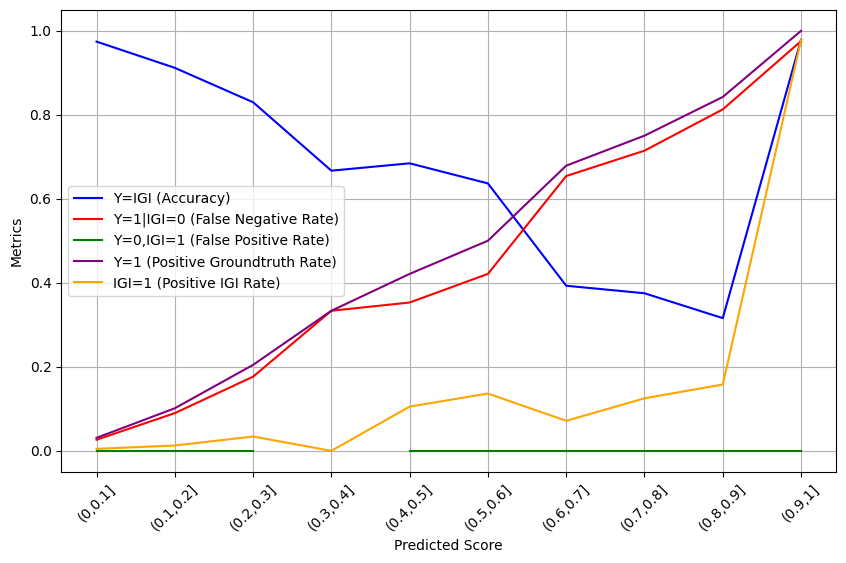

In [6]:
# bin_labels = pd.cut(test_pred_df.outputs, bins=10, include_lowest=True).cat.categories

bin_labels = ['(0,0.1]','(0.1,0.2]','(0.2,0.3]','(0.3,0.4]','(0.4,0.5]','(0.5,0.6]','(0.6,0.7]','(0.7,0.8]','(0.8,0.9]','(0.9,1]']
test_pred_df['output_bin'] = pd.cut(test_pred_df.outputs, bins=10, labels = range(10))

acc, fpr, fnr, pr, gt_pr = [],[],[],[],[]
for i in range(10):
    df = test_pred_df[test_pred_df.output_bin == i]
    tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, df.encoded_igi_call).ravel()
    acc.append((tp+tn)/df.shape[0])
    fpr.append((fp/(fp+tp)))
    fnr.append(fn/(fn+tn))
    pr.append((tp+fp)/df.shape[0])
    gt_pr.append(sum(df.groundtruth_label == 1)/df.shape[0])

plt.figure(figsize=(10,6))
plt.plot(range(10), acc, color = 'blue', label = 'Y=IGI (Accuracy)')
plt.plot(range(10), fnr, color = 'red', label = 'Y=1|IGI=0 (False Negative Rate)')
plt.plot(range(10), fpr, color = 'green', label='Y=0,IGI=1 (False Positive Rate)')
plt.plot(range(10), gt_pr, color = 'purple', label='Y=1 (Positive Groundtruth Rate)')
plt.plot(range(10), pr, color = 'orange', label = 'IGI=1 (Positive IGI Rate)')

plt.xticks(ticks=range(10),labels=bin_labels, rotation = 45)
plt.xlabel('Predicted Score')
plt.ylabel('Metrics')
plt.legend()
plt.grid()
plt.show()


/tmp/ipykernel_443879/749249095.py:13: RuntimeWarning: invalid value encountered in scalar divide
  fpr.append((fp/(fp+tp)))
/tmp/ipykernel_443879/749249095.py:13: RuntimeWarning: invalid value encountered in scalar divide
  fpr.append((fp/(fp+tp)))
/tmp/ipykernel_443879/749249095.py:13: RuntimeWarning: invalid value encountered in scalar divide
  fpr.append((fp/(fp+tp)))
/tmp/ipykernel_443879/749249095.py:13: RuntimeWarning: invalid value encountered in scalar divide
  fpr.append((fp/(fp+tp)))


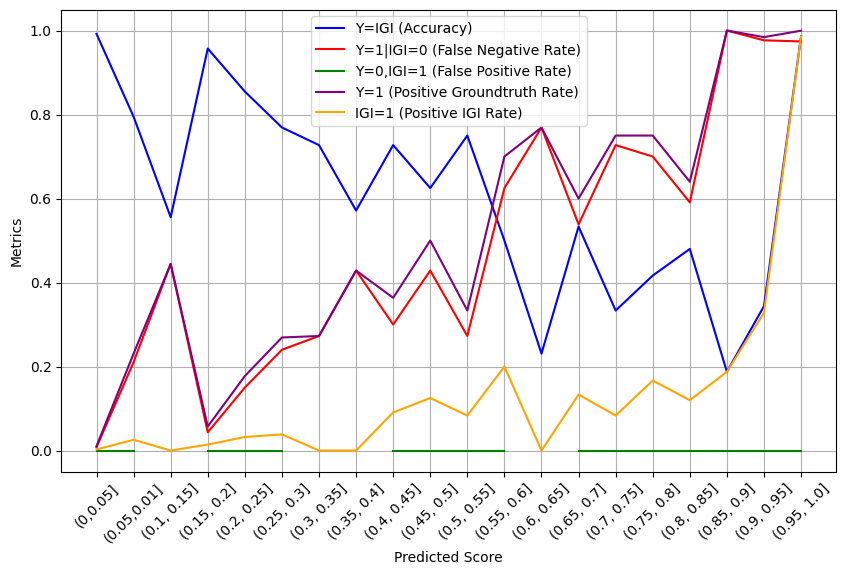

In [7]:
bin_labels = pd.cut(test_pred_df.outputs, bins=20, include_lowest=True).cat.categories.astype('str').to_list()
bin_labels[0] = '(0,0.05]'
bin_labels[1] = '(0.05,0.01]'

# bin_labels = ['(0,0.1]','(0.1,0.2]','(0.2,0.3]','(0.3,0.4]','(0.4,0.5]','(0.5,0.6]','(0.6,0.7]','(0.7,0.8]','(0.8,0.9]','(0.9,1]']
test_pred_df['output_bin'] = pd.cut(test_pred_df.outputs, bins=20, labels = range(20))

acc, fpr, fnr, pr, gt_pr = [],[],[],[],[]
for i in range(20):
    df = test_pred_df[test_pred_df.output_bin == i]
    tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, df.encoded_igi_call).ravel()
    acc.append((tp+tn)/df.shape[0])
    fpr.append((fp/(fp+tp)))
    fnr.append(fn/(fn+tn))
    pr.append((tp+fp)/df.shape[0])
    gt_pr.append(sum(df.groundtruth_label == 1)/df.shape[0])

plt.figure(figsize=(10,6))
plt.plot(range(20), acc, color = 'blue', label = 'Y=IGI (Accuracy)')
plt.plot(range(20), fnr, color = 'red', label = 'Y=1|IGI=0 (False Negative Rate)')
plt.plot(range(20), fpr, color = 'green', label='Y=0,IGI=1 (False Positive Rate)')
plt.plot(range(20), gt_pr, color = 'purple', label='Y=1 (Positive Groundtruth Rate)')
plt.plot(range(20), pr, color = 'orange', label = 'IGI=1 (Positive IGI Rate)')

plt.xticks(ticks=range(20),labels=bin_labels, rotation = 45)
plt.xlabel('Predicted Score')
plt.ylabel('Metrics')
plt.legend()
plt.grid()
plt.show()


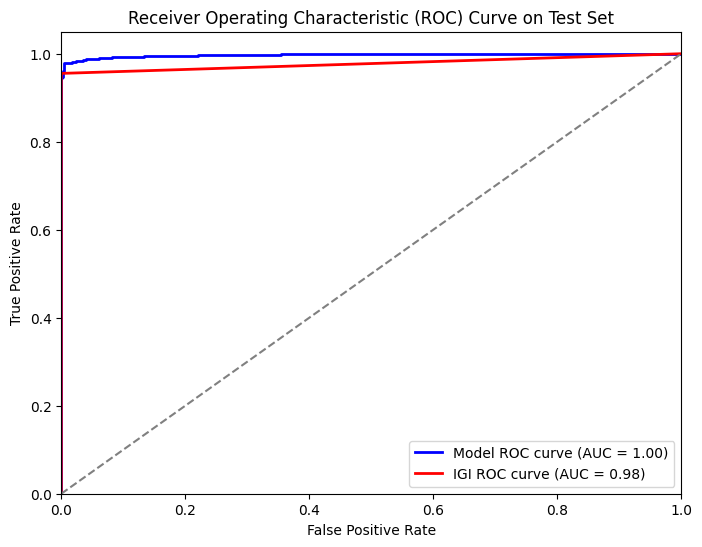

In [8]:
test_auc = roc_auc_score(test_pred_df.groundtruth_label, test_pred_df.outputs)
test_fpr, test_tpr, test_thresholds = roc_curve(test_pred_df.groundtruth_label, test_pred_df.outputs)

test_igi_auc = roc_auc_score(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)
test_igi_fpr, test_igi_tpr, test_igi_thresholds = roc_curve(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)

plt.figure(figsize=(8, 6))
plt.plot(test_fpr, test_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(test_auc))
plt.plot(test_igi_fpr, test_igi_tpr, color='red', lw=2, label='IGI ROC curve (AUC = {:.2f})'.format(test_igi_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Test Set')
plt.legend(loc='lower right')
plt.show()


In [18]:
tn, fp, fn, tp = confusion_matrix(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call).ravel()

igi_precision = tp/(fp + tp)
igi_sensitivity = tp/(tp + fn)
igi_specificity = tn/(tn + fp)
igi_f1 = 2*tp/(2*tp + fp + fn)
igi_acc = (tp+tn)/(tp+tn+fp+fn)
igi_neg_pred = sum(test_pred_df.encoded_igi_call == 0)

print('IGI AUC:', test_igi_auc)
print('True negative, false positive, false negative, true positive:', tn, fp, fn, tp)
print('IGI negative predictions:', igi_neg_pred)
print('IGI precision score:', igi_precision)
print('IGI sensitivity score:', igi_sensitivity)
print('IGI specificity:', igi_specificity)
print('IGI F1:', igi_f1)
print('IGI accuracy:', igi_acc)

IGI AUC: 0.9776389643309795
True negative, false positive, false negative, true positive: 621 0 247 5276
IGI negative predictions: 868
IGI precision score: 1.0
IGI sensitivity score: 0.955277928661959
IGI specificity: 1.0
IGI F1: 0.9771275118066488
IGI accuracy: 0.9597981770833334


In [10]:

# Define the number of true negatives and false negatives for different thresholds
# Replace these values with your actual data
thresholds = np.linspace(0.1, 1, 1000)
specificity, precision, accuracy, sensitivity  = [], [], [], []
for thres in thresholds:
    pred = 1*(test_pred_df.outputs >= thres)
    tn, fp, fn, tp = confusion_matrix(test_pred_df.groundtruth_label, pred).ravel()
    
    specificity.append(tn/(tn+fp))
    precision.append(tp/(tp+fp))
    accuracy.append((tp+tn)/len(pred))
    sensitivity.append(tp/(tp+fn))


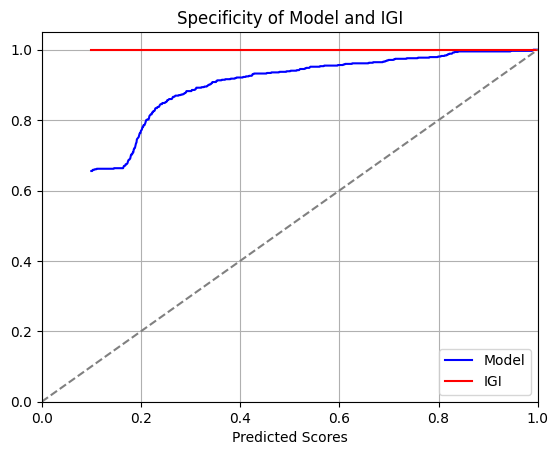

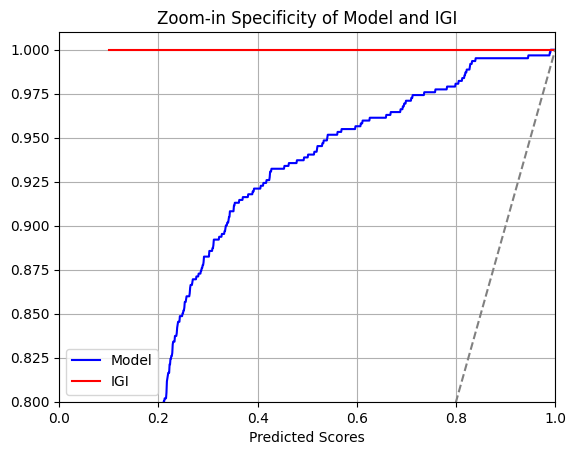

In [11]:
plt.plot(thresholds, specificity, color='blue', label='Model')
plt.plot(thresholds, [igi_specificity]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.legend()
plt.grid()
plt.title('Specificity of Model and IGI')
plt.show()

plt.plot(thresholds, specificity, color='blue', label='Model')
plt.plot(thresholds, [igi_specificity]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0.8, 1.01])
plt.legend()
plt.grid()
plt.title('Zoom-in Specificity of Model and IGI')
plt.show()


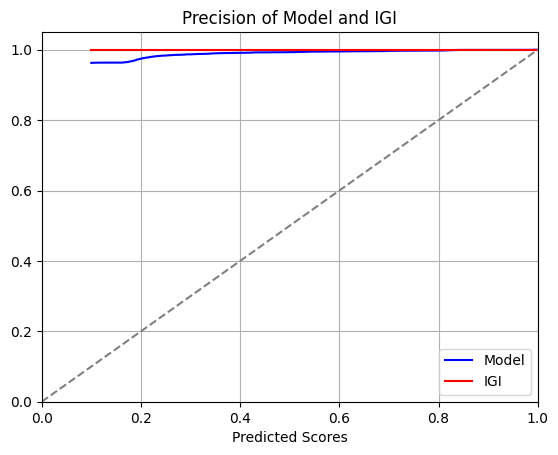

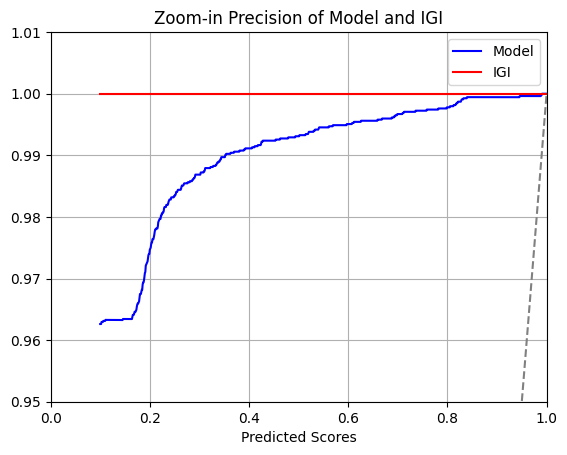

In [12]:
plt.plot(thresholds, precision, color='blue', label='Model')
plt.plot(thresholds, [igi_precision]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.legend()
plt.grid()
plt.title('Precision of Model and IGI')
plt.show()

plt.plot(thresholds, precision, color='blue', label='Model')
plt.plot(thresholds, [igi_precision]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0.95, 1.01])
plt.legend()
plt.grid()
plt.title('Zoom-in Precision of Model and IGI')
plt.show()


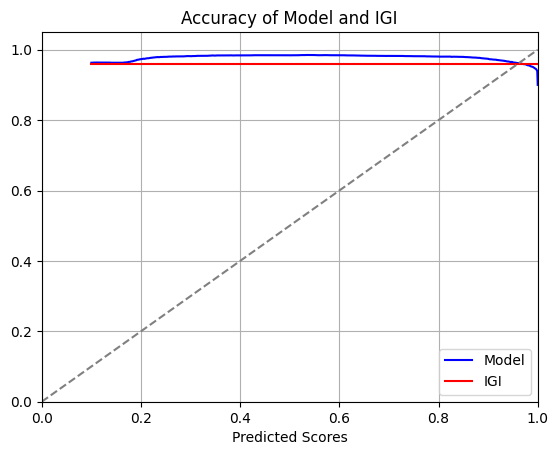

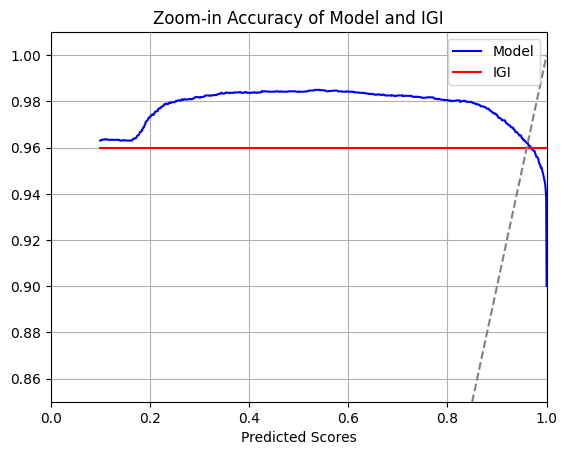

In [17]:
plt.plot(thresholds, accuracy, color='blue', label='Model')
plt.plot(thresholds, [igi_acc]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.legend()
plt.grid()
plt.title('Accuracy of Model and IGI')
plt.show()

plt.plot(thresholds, accuracy, color='blue', label='Model')
plt.plot(thresholds, [igi_acc]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0.85, 1.01])
plt.legend()
plt.grid()
plt.title('Zoom-in Accuracy of Model and IGI')
plt.show()


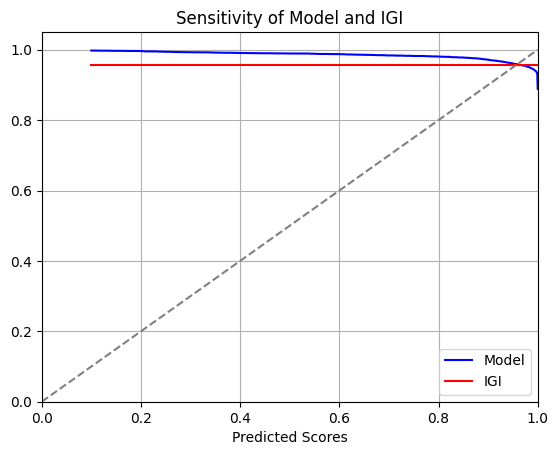

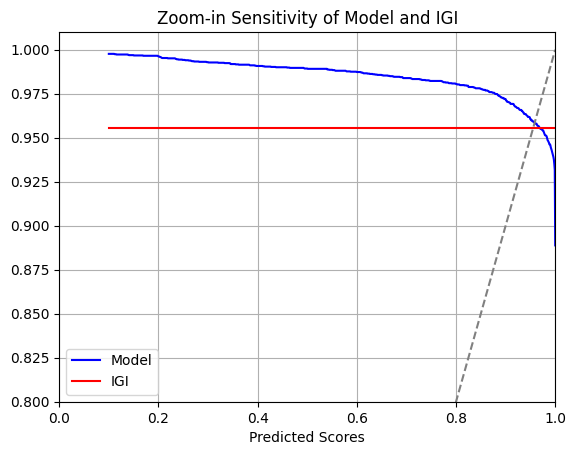

In [20]:
plt.plot(thresholds, sensitivity, color='blue', label='Model')
plt.plot(thresholds, [igi_sensitivity]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.legend()
plt.grid()
plt.title('Sensitivity of Model and IGI')
plt.show()

plt.plot(thresholds, sensitivity, color='blue', label='Model')
plt.plot(thresholds, [igi_sensitivity]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0.8, 1.01])
plt.legend()
plt.grid()
plt.title('Zoom-in Sensitivity of Model and IGI')
plt.show()
